# 1. Business understanding

 - Malli rakennetaan rintasyöpä datasta jossa on pahalaatuisia (malignan) ja hyvälaatuisia (benign)
 - Tavoitteena on ennustaa pahalaatuiset kasvaimet
 - Käytetään KNN-luokittelijaa
 - Mallin onnistumista arvioidaan tarkkuuden (accuracy) perusteella ensin ja sitten täsmällisyyden (precision) ja herkkyyden (recall)
 - Väärillä ennusteilla voi olla eri merkitys. Erityisesti malignant -> benign on vakava virhe

# 2. Data understanding

In [1]:
%pip install ucimlrepo
%pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
x = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

df = pd.concat([x, y], axis=1)

y = y['Diagnosis']

df

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


## Datan rakenne

### Muuttujat
- Diagnoosi (Diagnosis)
  - M = pahanlaatuinen (Malignant), B = hyvänlaatuinen (Benign)
- Säde (Radius) - etäisyyksien keskiarvo keskipisteestä reunaviivan pisteisiin
- Tekstuuri (Texture) - harmaasävyarvojen keskihajonta
- Ympärysmitta (Perimeter) (perimeter^2 / area - 1.0)
- Pinta-ala (Area)
- Sileys (Smoothness) - paikallinen vaihtelu säteen pituuksissa
- Tiiviys (Compactness)
- Koveruus (Concavity) - reunaviivan koverien osien voimakkuus
- Koverat pisteet (Concave points) - reunaviivan koverien osien määrä
- Symmetria (Symmetry)
- Fraktaaliulottuvuus (Fractal dimension) - “rantaviiva-approksimaatio” vähennettynä yhdellä

In [3]:
df.dtypes

radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3    float64
Diagnosis                 str
dtype: object

# 3. Data preparation

## X-akselin skaalaus käyttäen StandartScaler ja datan validointitestaus käyttäen split taktiikkaa

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

## Miksi kNN?
kNN perustuu havaintojen välisiin etäisyyksiin. Koska datasetin numeeriset muuttujat ovat eri mittakaavoissa, ne standardoitiin, jotta suuria lukuarvoja sisältävät muuttujat eivät hallitsisi etäisyyslaskentaa.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Jaetaan datasetti koulutus ja testi setteihin
# 66,7% käytetään koulutukseen ja 33,3% testiin
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.333, random_state=123)

# Skaalataan training-data
x_train_scaled = scaler.fit_transform(x_train)

# Skaalataan testidata samoilla training-datasta lasketuilla arvoilla
x_test_scaled = scaler.transform(x_test)

# 4. Modeling

In [6]:
for k in [1,3,5,7,9,11,13,15]:
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy with {k} neighbours: {accuracy:.5f}")

Accuracy with 1 neighbours: 0.96316
Accuracy with 3 neighbours: 0.98421
Accuracy with 5 neighbours: 0.96842
Accuracy with 7 neighbours: 0.97368
Accuracy with 9 neighbours: 0.96842
Accuracy with 11 neighbours: 0.97895
Accuracy with 13 neighbours: 0.97895
Accuracy with 15 neighbours: 0.97368


## Tarkkuuden tulkinta
Kaikki kokeillut k-arvot tuottivat korkean tarkkuuden. Paras tulos saatiin arvolla k=3, jolloin accuracy oli noin 98.4 %. Hold-out-menetelmän tulos riippuu valitusta train/test-jaosta, mutta tässä analyysissä random_state=123 pitää jaon samana jokaisella suorituskerralla.

# 5. Evaluation


Confusion matrix k:n arvolla 3:



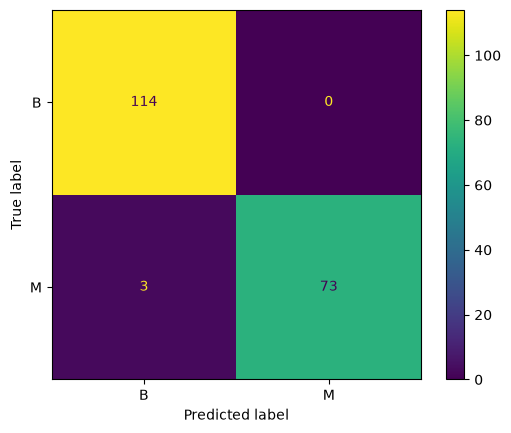


Klassifikointi raportti annetulla k arvolla 3

              precision    recall  f1-score   support

           B       0.97      1.00      0.99       114
           M       1.00      0.96      0.98        76

    accuracy                           0.98       190
   macro avg       0.99      0.98      0.98       190
weighted avg       0.98      0.98      0.98       190




In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt



model = KNeighborsClassifier(n_neighbors = 3)
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=['B', 'M'])
print("")
print("Confusion matrix k:n arvolla 3:")
print("")
cmd.plot()
plt.show()
print("")
print("Klassifikointi raportti annetulla k arvolla 3")
print("")
print(classification_report(y_test, y_pred))
print("")

## Confusion matrix purku

 - Malli luokitteli kaikki 114 bening luokkaa oikein
 - Malli luokitteli 73 malignant luokkaa oikein 76:sta
 - Kolme malignant-tapausta luokiteltiin virheellisesti benign-tapauksiksi (FN).
 - Benign-tapauksia ei luokiteltu virheellisesti malignant-tapauksiksi (FP = 0).
 - tarkkuus (accuracy) on 0.98
 - Malignant-luokan täsmällisyys (precision) oli 1.00.
 - Malignant-luokan herkkyys (recall) oli 0.96.

# 6. Deployment

Mallia voitaisiin periaatteessa käyttää uusien havaintojen luokitteluun, kun uusien näytteiden ominaisuudet standardoidaan samalla training-datasta sovitetulla scalerilla. Mallia ei kuitenkaan tämän analyysin perusteella tulisi käyttää todellisessa kliinisessä päätöksenteossa ilman huomattavasti laajempaa validointia. Jatkossa mallia voitaisiin testata suuremmalla ja riippumattomalla aineistolla.

### Precision, recall (koe tehtävä miten lasketaan matriisin avulla avvuracy, precision ja recall. accuracy on oikeet/kaikki, precision on true positive/ tp + false positive ks se dia)

# Muistiinpanoja
- knn toimii hyvin pieneen datasettiin
- antaa hyvän tuloksen
- raskas isolle datasetille
- jos dataa tulee lisää, voidaan lisätä eikä tarvitse tehdä uusiksi